In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

rng = np.random.default_rng()

In [20]:
nsamples = 200
smallest_window = 3
ncontours = 1 + 2*(nctrs := 2)

In [7]:
gaussian = rng.normal(10, 1, (nsamples))
signal = np.sin(np.linspace(0,40, (nsamples)))
poisson = rng.poisson(10, (nsamples))
uniform = rng.uniform(9,11, (nsamples))

In [3]:
def meanspectrum(array):
    datasequence = np.ravel(array)
    datalen = len(datasequence)
    windowlens = np.arange(smallest_window, 1 + datalen//2)

    windowmeans = []
    for windowlen in windowlens:
        windows = np.arange(datalen - windowlen + 1)[:, None] + np.arange(windowlen)
        windowmeans.append(np.mean(datasequence[windows], axis=1))
    return windowmeans

In [9]:
import SAIfunc_20260217 as sai
from pathlib import Path

In [26]:
activesim = sai.Sim.fromfile(Path('./data/SAIsim-20260310_065510'), 10)


Read 200 from data/SAIsim-20260310_065510.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.2, 'a0': 4.0, 'a1': 4.0}


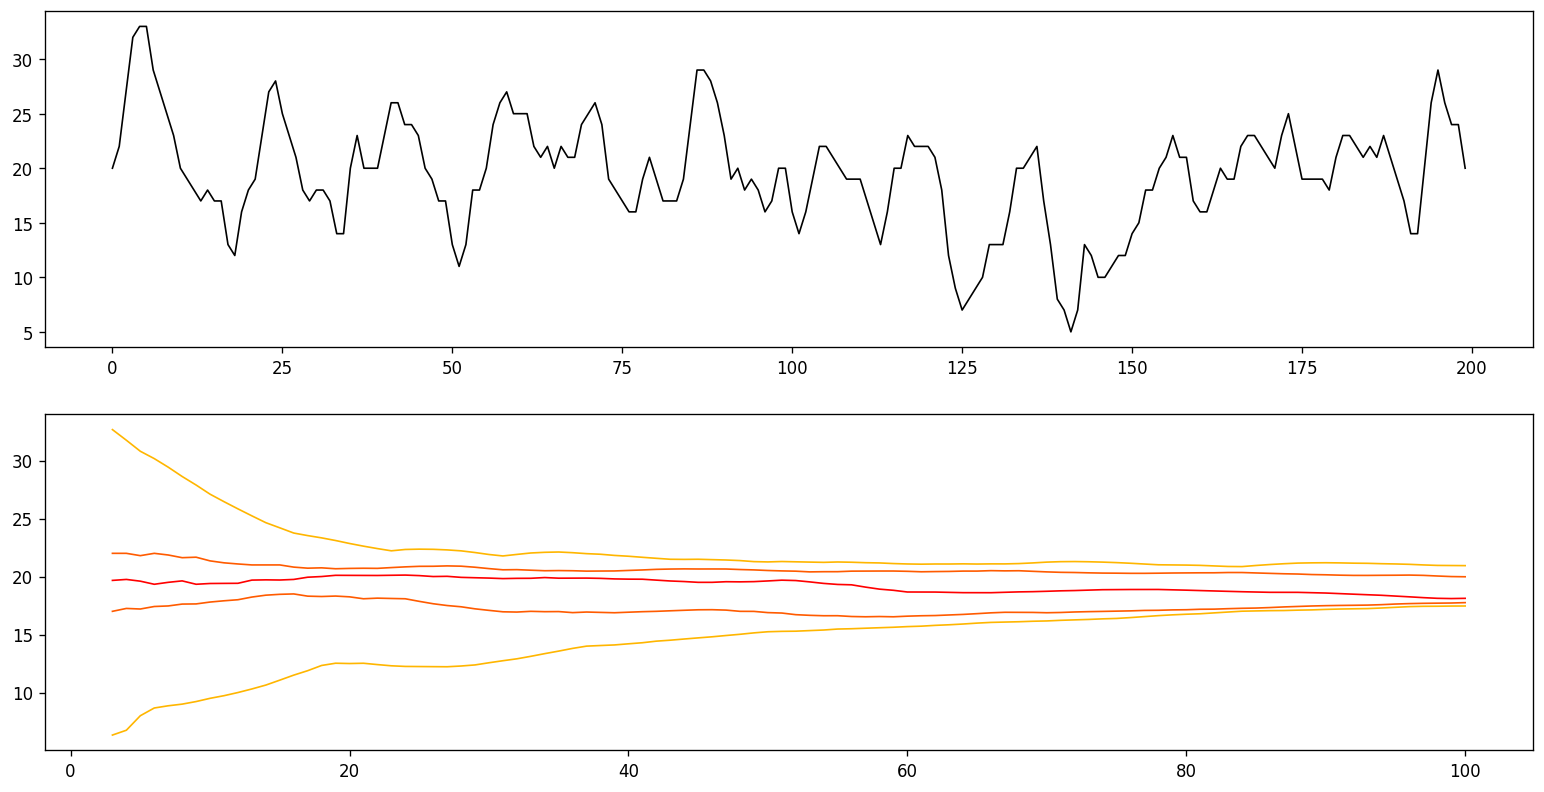

In [27]:
f = plt.figure(figsize=(16,8), dpi=120)
ax1, ax2 = f.subplots(nrows=2, ncols=1)

src = np.count_nonzero(activesim.all()[0], axis=1)

ax1.plot(src, color='black', linewidth=1)

winquantiles = []
for meanset in meanspectrum(src):
    winquantiles.append(np.quantile(meanset, np.linspace(0,1, ncontours)))

plt.rcParams["axes.prop_cycle"] = cycler(
    color=[ (1, abs(r-nctrs)/(1.4*nctrs), 0)  for r in range(ncontours)]
)
ax2.plot(np.arange(smallest_window, 1 + nsamples//2), winquantiles, linewidth=1)

plt.show()